In [1]:
import os
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma, erf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf
# import modelnn2 as thf

import json
import gc
import glob
from pathlib import Path

I0000 00:00:1780331506.418835  752895 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780331506.458686  752895 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780331507.796625  752895 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780331509.138362  752895 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

# Data Loading

Using dask we are able to extract critical informations such as the number of features in the dataset and the sample sizes of both train and test samples.

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../train_data.parquet')
metadata_val = pq.read_metadata('../val_data.parquet')
metadata_test = pq.read_metadata('../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_val = metadata_val.num_rows
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_val = num_rows_val
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Validação".format(n_val))
print("{} colunas - Teste".format(n_test))

94 features
8786689 colunas - Treino
2928897 colunas - Validação
3905196 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../train_data.parquet"
parquet_file_path_val = "../val_data.parquet"
parquet_file_path_test = "../test_data.parquet"

parquet_reader_train = pq.ParquetFile(parquet_file_path_train)
parquet_reader_val = pq.ParquetFile(parquet_file_path_val)
parquet_reader_test = pq.ParquetFile(parquet_file_path_test)

def tabular_batch_generator_train(time_col, event_col, batch_size):
    time_col = time_col.decode("utf-8")
    event_col = event_col.decode("utf-8")
    
    # Pull data from parquet file iteratively in chunks
    for batch in parquet_reader_train.iter_batches(batch_size = batch_size):
        # Convert table to pandas DataFrame for column sclicing
        df = batch.to_pandas()

        # Obtain the time and censorship information from the dataset
        time = df[time_col].values.reshape(-1, 1)
        event = df[event_col].values.reshape(-1, 1)
        # Remove the response variable values from the table
        X = df.drop(columns = [time_col, event_col])
        
        # Yield the exact tuple structure thetaflow expects: (X, time, event) as a generator
        yield (X, time, event)

def tabular_batch_generator_val(time_col, event_col, batch_size):
    time_col = time_col.decode("utf-8")
    event_col = event_col.decode("utf-8")
    
    # Pull data from parquet file iteratively in chunks
    for batch in parquet_reader_val.iter_batches(batch_size = batch_size):
        # Convert table to pandas DataFrame for column sclicing
        df = batch.to_pandas()

        # Obtain the time and censorship information from the dataset
        time = df[time_col].values.reshape(-1, 1)
        event = df[event_col].values.reshape(-1, 1)
        # Remove the response variable values from the table
        X = df.drop(columns = [time_col, event_col])
        
        # Yield the exact tuple structure thetaflow expects: (X, time, event) as a generator
        yield (X, time, event)

def tabular_batch_generator_test(time_col, event_col, batch_size):
    time_col = time_col.decode("utf-8")
    event_col = event_col.decode("utf-8")
    
    # Pull data from parquet file iteratively in chunks
    for batch in parquet_reader_test.iter_batches(batch_size = batch_size):
        # Convert table to pandas DataFrame for column sclicing
        df = batch.to_pandas()

        # Obtain the time and censorship information from the dataset
        time = df[time_col].values.reshape(-1, 1)
        event = df[event_col].values.reshape(-1, 1)
        # Remove the response variable values from the table
        X = df.drop(columns = [time_col, event_col])
        
        # Yield the exact tuple structure thetaflow expects: (X, time, event) as a generator
        yield (X, time, event)

In [4]:
train_batch_size = 150000
train_ds = tf.data.Dataset.from_generator(
    tabular_batch_generator_train,
    args=("tempo", "delta", train_batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, n_features), dtype = tf.float32),
        tf.TensorSpec(shape=(None,1), dtype = tf.float32),
        tf.TensorSpec(shape=(None,1), dtype = tf.float32)
    )
)

num_batches_train = int(np.ceil( n_train / train_batch_size ))

# Keep the GPU fed during optimization
train_ds = (
    train_ds
    .apply( tf.data.experimental.assert_cardinality(num_batches_train) )
    .prefetch(tf.data.AUTOTUNE)
)

In [5]:
val_batch_size = 150000
val_ds = tf.data.Dataset.from_generator(
    tabular_batch_generator_val,
    args=("tempo", "delta", val_batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, n_features), dtype = tf.float32),
        tf.TensorSpec(shape=(None,1), dtype = tf.float32),
        tf.TensorSpec(shape=(None,1), dtype = tf.float32)
    )
)

num_batches_val = int(np.ceil( n_val / val_batch_size ))

# Keep the GPU fed during optimization
val_ds = (
    val_ds
    .apply( tf.data.experimental.assert_cardinality(num_batches_val) )
    .prefetch(tf.data.AUTOTUNE)
)

In [6]:
test_batch_size = 150000
test_ds = tf.data.Dataset.from_generator(
    tabular_batch_generator_test,
    args=("tempo", "delta", test_batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, n_features), dtype = tf.float32),
        tf.TensorSpec(shape=(None,1), dtype = tf.float32),
        tf.TensorSpec(shape=(None,1), dtype = tf.float32)
    )
)

num_batches_test = int(np.ceil( n_test / test_batch_size ))
# Keep the GPU fed during optimization
test_ds = (
    test_ds
    .apply( tf.data.experimental.assert_cardinality(num_batches_test) )
    .prefetch(tf.data.AUTOTUNE)
)

# Mixture Lognormal Model

In [7]:
def build_mixture_lognormal_model( dropout_rate = 0.1, ridge_penalty = 0.01, lasso_penalty = 0.01 ):
    def logit(u):
        return -( tf.math.log(1-u) - tf.math.log(u) )
        
    mixture_lognormal_parameters = {
        "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 0.0},
        "sigma": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0},
        "p": {"link": tf.math.sigmoid, "link_inv": logit, "par_type": "nn", "shape": 1, "init": 0.5, "warmup_time": 0}
    }

    def loglikelihood_loss(model, nn_output, data):
        # Unpack your data tuple
        X, y, delta = data
        
        sigma = model.get_variable("sigma")
        mu = model.get_variable("mu", nn_output)
        p = model.get_variable("p", nn_output)

        constant1 = tf.constant(1, dtype = tf.float32)
        constant2 = tf.constant(2, dtype = tf.float32)
        log_y = tf.math.log(y + 1.0e-7)
        z = (log_y - mu) / sigma

        S0 = 0.5 * tf.math.erfc(z / tf.math.sqrt(constant2))
        log_f0 = -log_y - tf.math.log(sigma) - z**constant2 / constant2

        loglik_terms = delta * (tf.math.log(1-p) + log_f0) + (1.0 - delta) * tf.math.log(p + (1-p)*S0)
        neg_loglik = -tf.reduce_sum(loglik_terms)
        
        return neg_loglik

    def neural_network(model, input_dim=100, seed=None):
        initializer = tf.keras.initializers.GlorotNormal(seed=seed)
        
        elastic_net = tf.keras.regularizers.L1L2(l1 = lasso_penalty, l2 = ridge_penalty)
        
        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer,
            kernel_regularizer = elastic_net,
            name = "tabular_features_extractor"
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_1"
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer,
            name = "interaction_layer_2"
        )
        model.output_layer = layers.Dense(
            units = 2,
            activation = None, # Linear, o exponente fica na Loss function
            kernel_initializer = initializer,
            name = "log_lambda_output"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        return x

    return mixture_lognormal_parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [8]:
# with tf.device("/GPU:0"):
#     mixture_lognormal_parameters, mixture_lognormal_loss, mixture_lognormal_neural_network, mixture_lognormal_call, mixture_lognormal_call_nolast = \
#     build_mixture_lognormal_model( ridge_penalty = 0.001, lasso_penalty = 0.001 )
#     seed = 10
#     mixture_lognormal_model = thf.ModelNN(mixture_lognormal_parameters, mixture_lognormal_loss,
#                                         mixture_lognormal_neural_network, mixture_lognormal_call,
#                                         mixture_lognormal_call_nolast, input_dim = (n_features,), seed = seed)
#     mixture_lognormal_model.pre_train_model(epochs = None, x = train_ds, data = None, n_train = n_train, shuffle = True)
#     mixture_lognormal_model.train_model(epochs = 1200, x = train_ds, data = None, n_train = n_train,
#                                       shuffle = True,
#                                       get_covariances = True,
#                                       validation = True, x_val = val_ds, n_val = n_val,
#                                       force_training_validation = False,
#                                       optimizer_independent = optimizers.Adam(learning_rate = 0.0001, clipnorm = 1.0),
#                                       optimizer_nn = optimizers.Adam(learning_rate = 0.0001, clipnorm = 1.0),
#                                       fine_tune_nn_lr = 0.0001, fine_tune_independent_lr = 0.0001,
#                                       early_stopping = True, early_stopping_patience = 50, 
#                                       early_stopping_warmup = 10,
#                                       reduce_lr = True, reduce_lr_warmup = 0,
#                                       reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
#                                       reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
#                                       fine_tune = True,
#                                       finetune_early_stopping = True, finetune_early_stopping_patience = 50,
#                                       finetune_early_stopping_warmup = 10,
#                                       finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
#                                       finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
#                                       finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
#                                       deterministic = True,
#                                       verbose = True, print_freq = 1,
#                                       train_batch_size = None, val_batch_size = None,
#                                       buffer_size = None, gradient_accumulation_steps = 1)

In [9]:
# mixture_lognormal_model.save_model("mixture_lognormal_model")

In [10]:
mixture_lognormal_parameters, mixture_lognormal_loss, mixture_lognormal_neural_network, mixture_lognormal_call, mixture_lognormal_call_nolast = \
build_mixture_lognormal_model( ridge_penalty = 0.001, lasso_penalty = 0.001 )
seed = 10
mixture_lognormal_model = thf.ModelNN(mixture_lognormal_parameters, mixture_lognormal_loss,
                                      mixture_lognormal_neural_network, mixture_lognormal_call,
                                      mixture_lognormal_call_nolast, input_dim = (n_features,), seed = seed)
mixture_lognormal_model.load_model("mixture_lognormal_model")

Model successfully loaded from mixture_lognormal_model.


/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'model_nn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [11]:
y_train = np.array([])
delta_train = np.array([])
for batch in train_ds:
    X, y, delta = batch
    y = y.numpy().flatten()
    delta = delta.numpy().flatten()
    y_train = np.concatenate([y_train, y])
    delta_train = np.concatenate([delta_train, delta])
y_train

I0000 00:00:1780331510.452932  752895 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


array([21.        , 15.30000019,  8.39999962, ..., 22.10000038,
       13.19999981, 20.89999962], shape=(8786689,))

In [12]:
y_test = np.array([])
delta_test = np.array([])
for batch in test_ds:
    X, y, delta = batch
    y = y.numpy().flatten()
    delta = delta.numpy().flatten()
    y_test = np.concatenate([y_test, y])
    delta_test = np.concatenate([delta_test, delta])
y_test

array([ 4.80000019, 17.        , 27.10000038, ..., 20.79999924,
       14.10000038, 15.80000019], shape=(3905196,))

In [13]:
pars_train = mixture_lognormal_model.predict(train_ds)
pars_test = mixture_lognormal_model.predict(test_ds)

sigma_train = mixture_lognormal_model.predict("sigma")
sigma_test = sigma_train.copy()
# sigma_train = pars_train["sigma"].numpy().flatten()
# sigma_test = pars_test["sigma"].numpy().flatten()

mu_train = pars_train["mu"].numpy().flatten()
p_train = pars_train["p"].numpy().flatten()
mu_test = pars_test["mu"].numpy().flatten()
p_test = pars_test["p"].numpy().flatten()

ts_grid_max = np.max(np.concatenate([y_train, y_test]))
ts_grid = np.linspace(0.0001 , ts_grid_max, 100)[:,None]
S_ts_train = p_train + (1-p_train) * 0.5 * (1 - erf(np.log(ts_grid) - mu_train / sigma_train))
S_ts_test = p_test + (1-p_test) * 0.5 * (1 - erf(np.log(ts_grid) - mu_test / sigma_test))

S_train = p_train + (1-p_train) * 0.5 * (1 - erf(np.log(y_train) - mu_train / sigma_train))
S_test = p_test + (1-p_test) * 0.5 * (1 - erf(np.log(y_test) - mu_test / sigma_test))
H_train = -np.log( S_train )
H_test = -np.log( S_test )

expected_time_lived_train = np.trapezoid(S_ts_train, x = ts_grid.flatten(), axis = 0)
expected_time_lived_test = np.trapezoid(S_ts_test, x = ts_grid.flatten(), axis = 0)

# Lower expected time = higher risk (these are NEGATIVE numbers)
risk_score_train = -expected_time_lived_train
risk_score_test = -expected_time_lived_test

In [14]:
import gndr_utils as utils

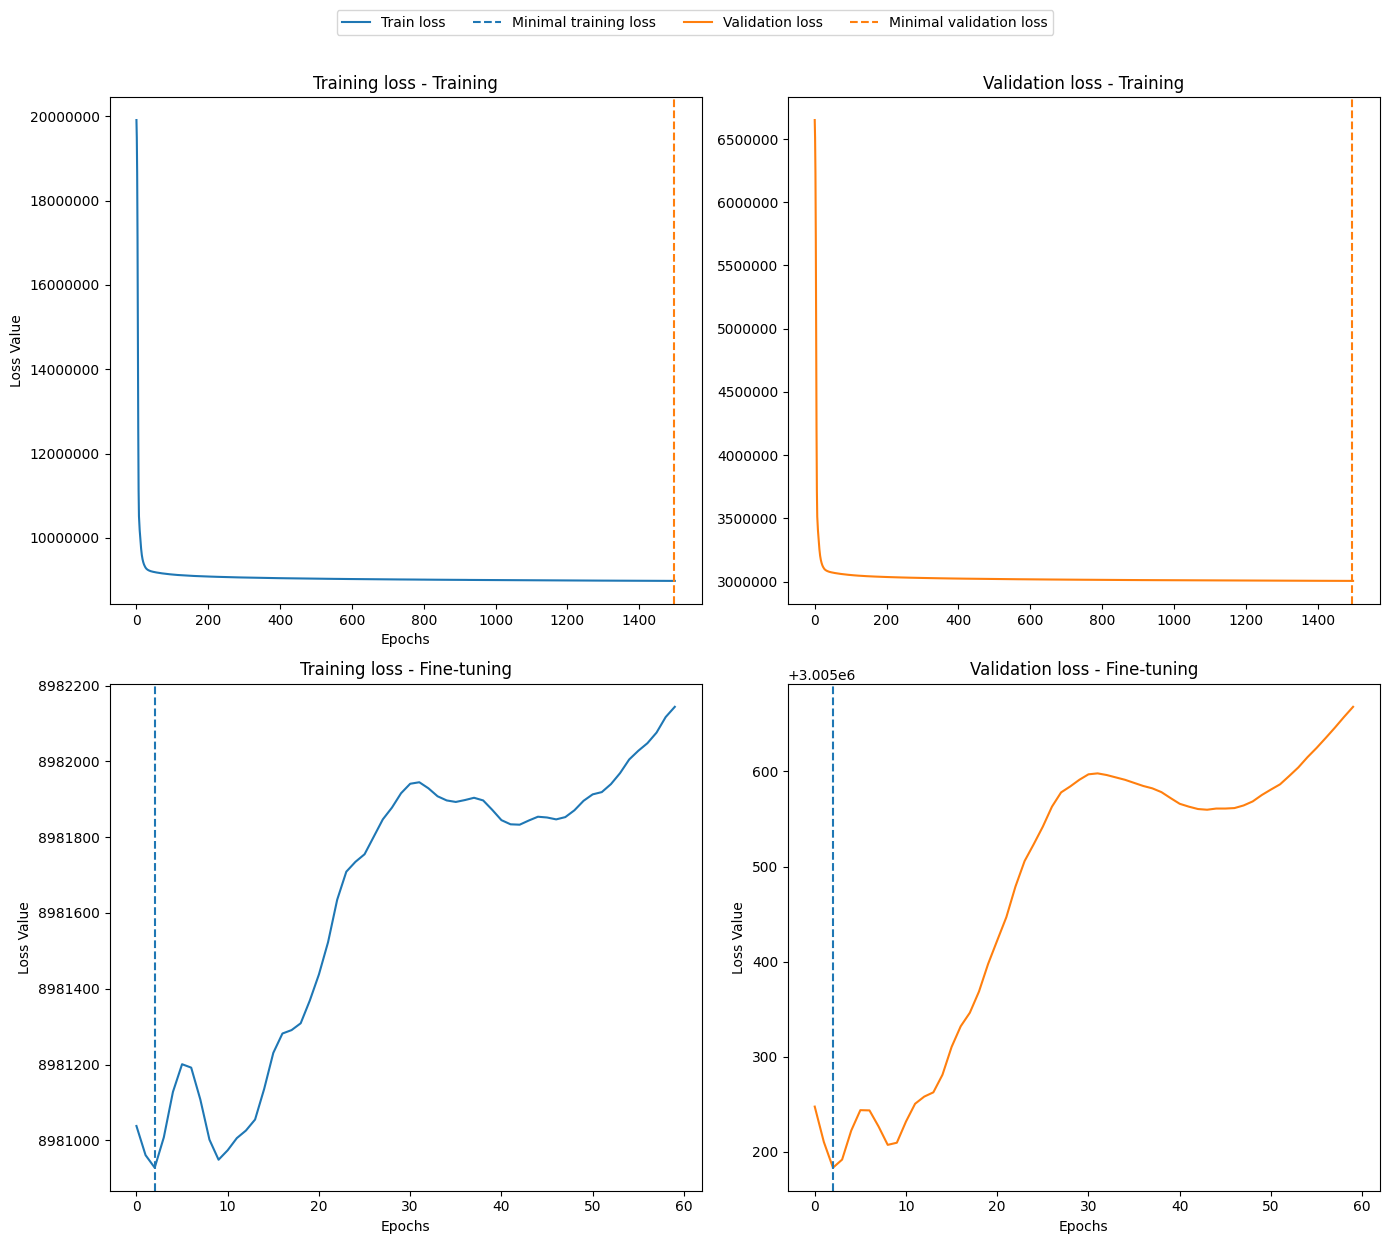

In [15]:
utils.plot_model_convergence( mixture_lognormal_model )

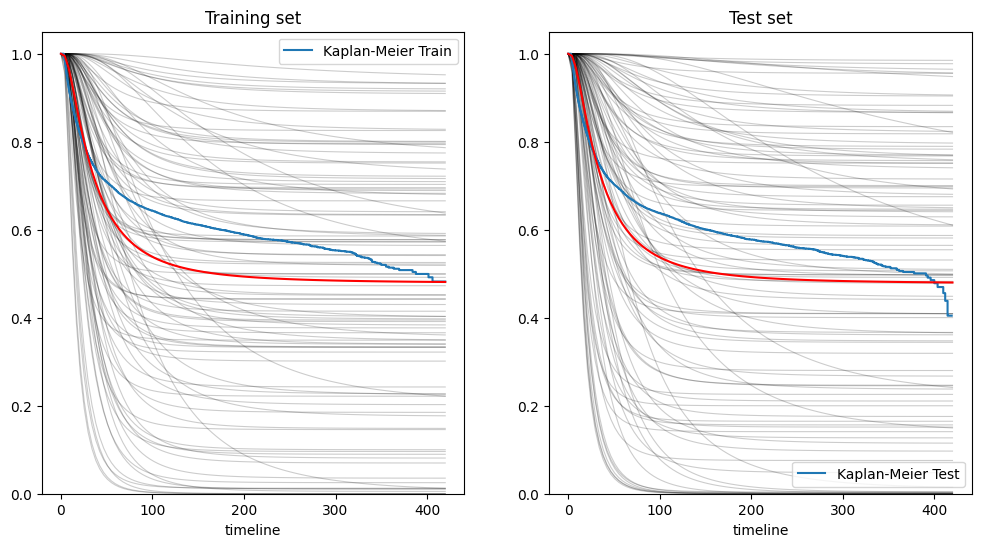

In [16]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
np.random.seed(10)
n_max = 100000
indices_train = np.random.choice(np.array(n_train), size = n_max)
indices_test = np.random.choice(np.array(n_test), size = n_max)
utils.average_kaplan_meier(ts_grid,
                           S_ts_train[:, indices_train], S_ts_test[:, indices_test],
                           y_train[indices_train], delta_train[indices_train], y_test[indices_test], delta_test[indices_test], show_individual = True, ax1 = ax[0], ax2 = ax[1])